In [ ]:
# 1. Kết nối MotherDuck và đọc dữ liệu Gold
!pip install duckdb -q

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

TOKEN = userdata.get("motherduck")

con = duckdb.connect(f"md:?motherduck_token={TOKEN}")

gold = con.execute("""
SELECT *
FROM vanh_gold.wide_table_ml
""").df()

gold.head()

,order_id,customer_segment,customer_country,customer_state,shipping_mode,market,order_region,order_type,category_name,department_name,...,order_item_quantity,days_for_shipment_scheduled,order_month,order_quarter,order_weekday,profit_margin,discount_ratio,sales_per_item,is_weekend,late_delivery_risk
0,77202,CONSUMER,PUERTO RICO,PR,Standard Class,PACIFIC ASIA,SOUTHEAST ASIA,DEBIT,Sporting Goods,Fitness,...,1,4,1,1,3,0.278413,0.040000,327.75,0,0
1,75937,HOME OFFICE,EE. UU.,CA,Standard Class,PACIFIC ASIA,OCEANIA,DEBIT,Sporting Goods,Fitness,...,1,4,1,1,6,0.069748,0.069992,327.75,1,0
2,75936,CORPORATE,PUERTO RICO,PR,Standard Class,PACIFIC ASIA,OCEANIA,PAYMENT,Sporting Goods,Fitness,...,1,4,1,1,6,0.409489,0.090008,327.75,1,0
3,75935,CONSUMER,EE. UU.,NY,Standard Class,PACIFIC ASIA,OCEANIA,TRANSFER,Sporting Goods,Fitness,...,1,4,1,1,6,0.056690,0.100015,327.75,1,0
4,75934,HOME OFFICE,PUERTO RICO,PR,First Class,PACIFIC ASIA,EASTERN ASIA,DEBIT,Sporting Goods,Fitness,...,1,1,1,1,6,0.290404,0.120000,327.75,1,1


In [ ]:
# 2. Tổng quan dữ liệu Gold
print("Số dòng:", gold.shape[0])
print("Số cột:", gold.shape[1])

gold.info()

Số dòng: 114187
Số cột: 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114187 entries, 0 to 114186
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_id                     114187 non-null  object 
 1   customer_segment             114187 non-null  object 
 2   customer_country             114187 non-null  object 
 3   customer_state               114187 non-null  object 
 4   shipping_mode                114187 non-null  object 
 5   market                       114187 non-null  object 
 6   order_region                 114187 non-null  object 
 7   order_type                   114187 non-null  object 
 8   category_name                114187 non-null  object 
 9   department_name              114187 non-null  object 
 10  product_price                114187 non-null  float64
 11  sales_amount                 114187 non-null  float64
 12  profit                       11

In [ ]:
# 3. Danh sách biến và kiểu dữ liệu
gold_dict = pd.DataFrame({
    "column_name": gold.columns,
    "dtype": gold.dtypes.astype(str).values,
    "non_null_count": gold.notnull().sum().values,
    "null_count": gold.isnull().sum().values,
    "null_rate": (gold.isnull().mean() * 100).round(2).values,
    "unique_count": gold.nunique(dropna=True).values
})

gold_dict

,column_name,dtype,non_null_count,null_count,null_rate,unique_count
0,order_id,object,114187,0,0.0,42386
1,customer_segment,object,114187,0,0.0,3
2,customer_country,object,114187,0,0.0,2
3,customer_state,object,114187,0,0.0,46
4,shipping_mode,object,114187,0,0.0,4
5,market,object,114187,0,0.0,5
6,order_region,object,114187,0,0.0,22
7,order_type,object,114187,0,0.0,4
8,category_name,object,114187,0,0.0,50
9,department_name,object,114187,0,0.0,11


In [ ]:
# 4a. Kiểm tra dữ liệu thiếu sau xử lý
missing_gold = gold.isnull().sum()
missing_gold = missing_gold[missing_gold > 0].sort_values(ascending=False)

missing_gold

,0


In [ ]:
# 4b. Kiểm tra trùng lặp trong Gold / wide_table_ml

total_rows = len(gold)

full_duplicate_rows = gold.duplicated().sum()

unique_order_id = gold["order_id"].nunique()
duplicate_order_id = gold["order_id"].duplicated().sum()

print("Tổng số dòng:", total_rows)
print("Số dòng trùng lặp hoàn toàn:", full_duplicate_rows)
print("Số order_id duy nhất:", unique_order_id)
print("Số order_id bị lặp:", duplicate_order_id)

if full_duplicate_rows == 0:
    print("Kết luận: Không có dòng trùng lặp hoàn toàn trong wide_table_ml.")
else:
    print("Kết luận: Có dòng trùng lặp hoàn toàn, cần kiểm tra lại.")

print("Lưu ý: order_id có thể bị lặp vì một đơn hàng có thể gồm nhiều sản phẩm/order item.")

Tổng số dòng: 114187
Số dòng trùng lặp hoàn toàn: 0
Số order_id duy nhất: 42386
Số order_id bị lặp: 71801
Kết luận: Không có dòng trùng lặp hoàn toàn trong wide_table_ml.
Lưu ý: order_id có thể bị lặp vì một đơn hàng có thể gồm nhiều sản phẩm/order item.


In [ ]:
# 5. Phân loại biến trong bộ dữ liệu Gold
target_col = "late_delivery_risk"

id_cols = ["order_id"]

numeric_cols = gold.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = gold.select_dtypes(include=["object"]).columns.tolist()

numeric_features = [col for col in numeric_cols if col != target_col]
categorical_features = [col for col in categorical_cols if col not in id_cols]

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 13
['product_price', 'sales_amount', 'profit', 'discount', 'order_item_quantity', 'days_for_shipment_scheduled', 'order_month', 'order_quarter', 'order_weekday', 'profit_margin', 'discount_ratio', 'sales_per_item', 'is_weekend']

Categorical features: 9
['customer_segment', 'customer_country', 'customer_state', 'shipping_mode', 'market', 'order_region', 'order_type', 'category_name', 'department_name']


In [ ]:
# 6. Phân bố biến mục tiêu
target_count = gold[target_col].value_counts().sort_index()
target_rate = (gold[target_col].value_counts(normalize=True).sort_index() * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_count,
    "rate_percent": target_rate
})

target_summary

,count,rate_percent
late_delivery_risk,,
0,51475,45.08
1,62712,54.92


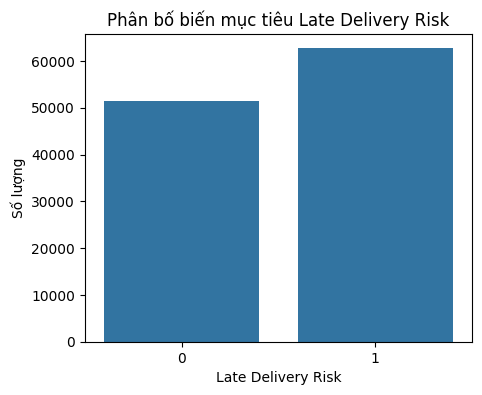

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data=gold, x=target_col)
plt.title("Phân bố biến mục tiêu Late Delivery Risk")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Số lượng")
plt.show()

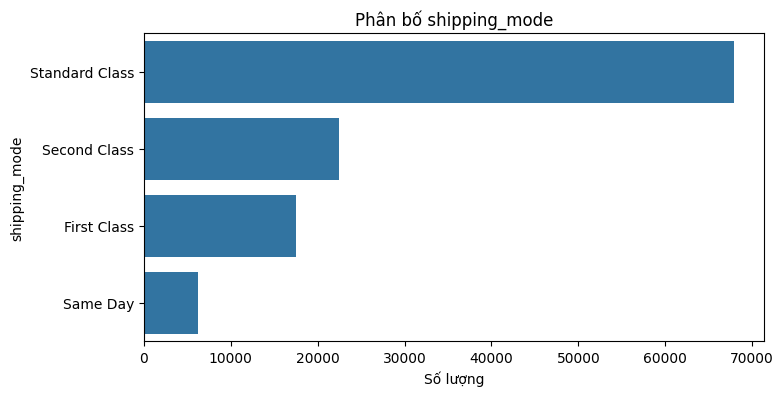

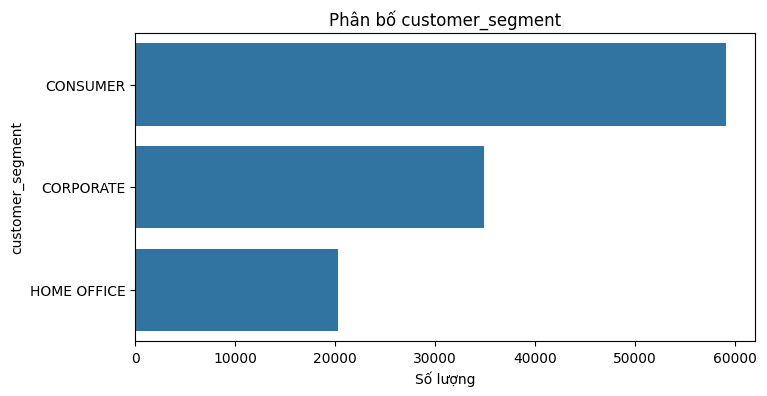

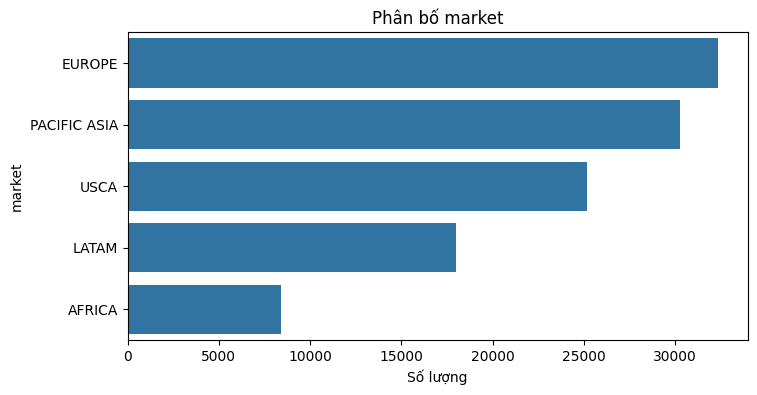

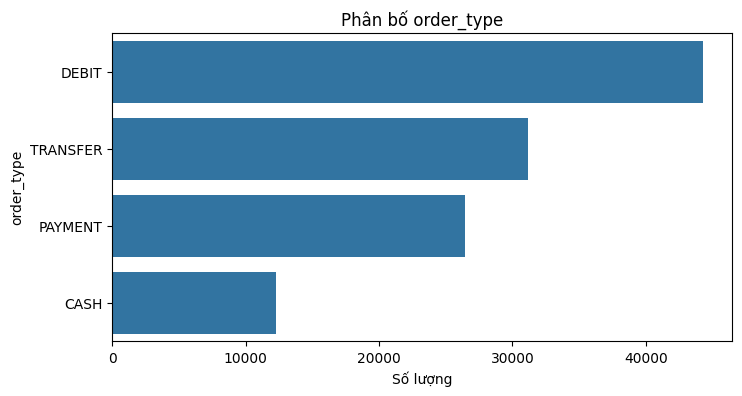

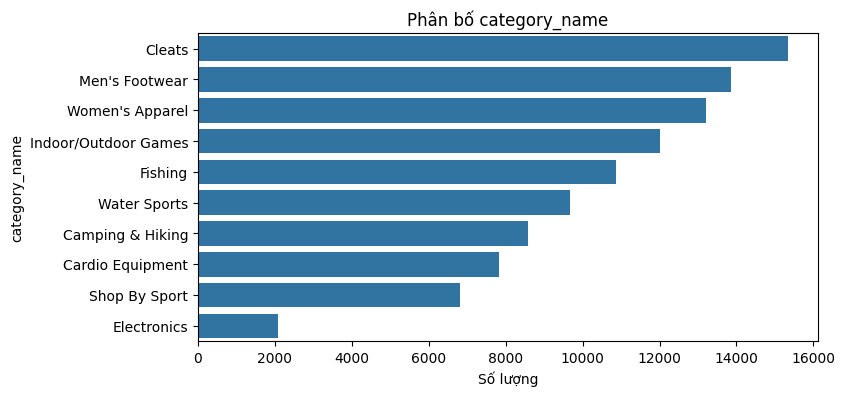

In [ ]:
# 7. Phân bố các biến phân loại quan trọng
cat_cols_to_plot = [
    "shipping_mode",
    "customer_segment",
    "market",
    "order_type",
    "category_name"
]

for col in cat_cols_to_plot:
    plt.figure(figsize=(8, 4))
    order = gold[col].value_counts().head(10).index
    sns.countplot(data=gold, y=col, order=order)
    plt.title(f"Phân bố {col}")
    plt.xlabel("Số lượng")
    plt.ylabel(col)
    plt.show()

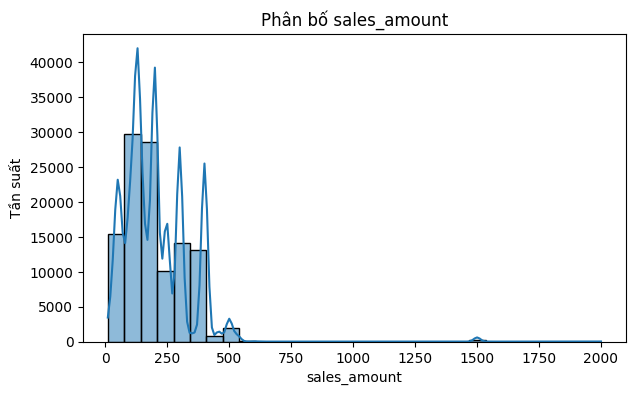

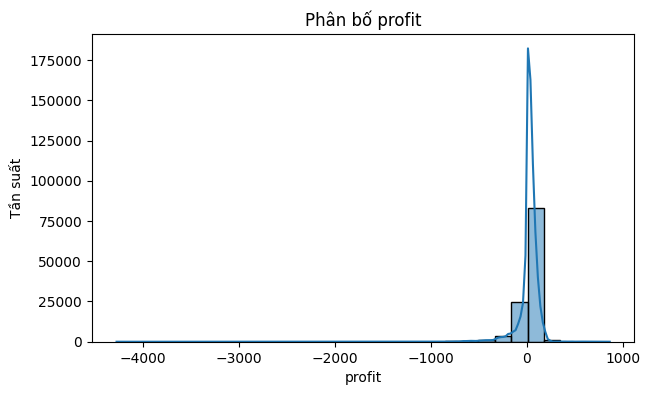

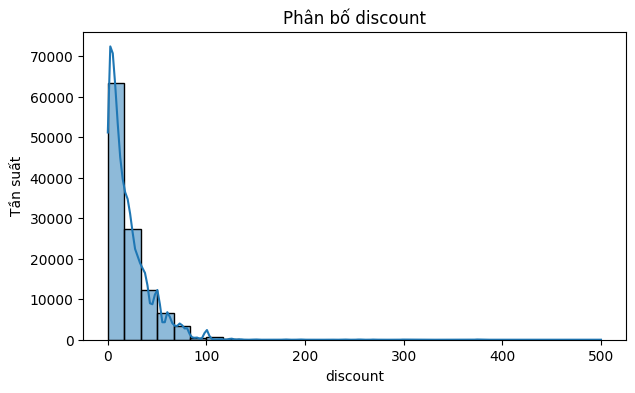

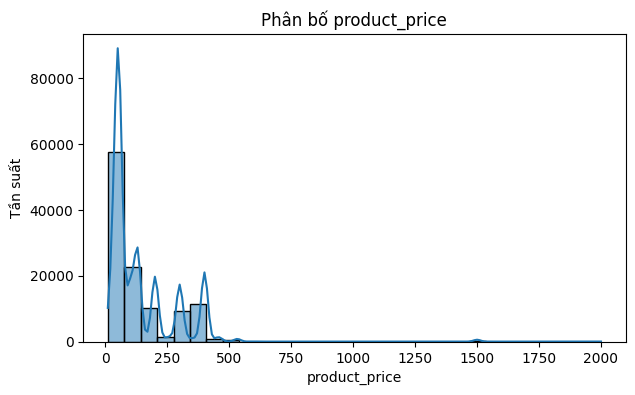

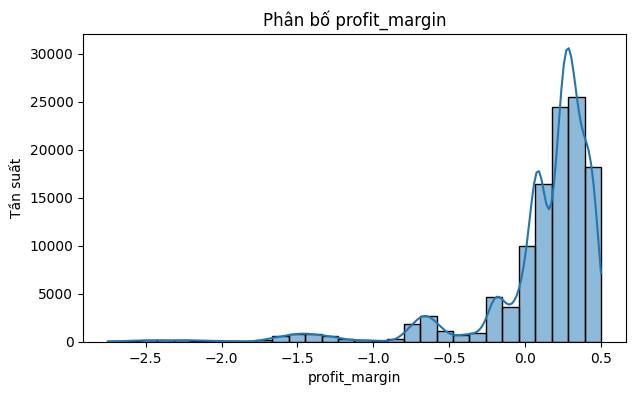

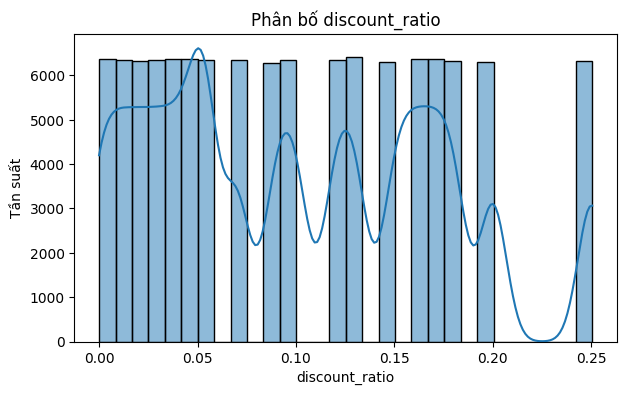

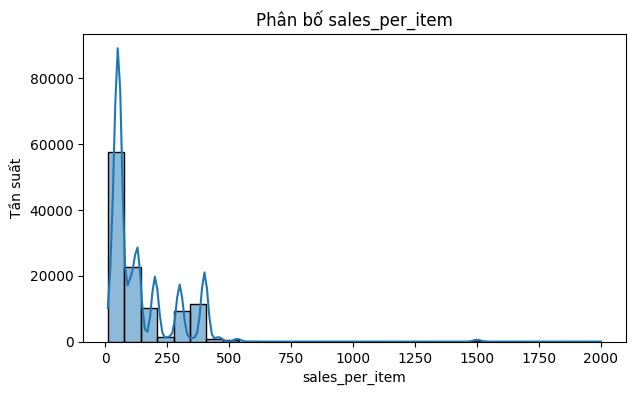

In [ ]:
# 8. Phân bố các biến số quan trọng
num_cols_to_plot = [
    "sales_amount",
    "profit",
    "discount",
    "product_price",
    "profit_margin",
    "discount_ratio",
    "sales_per_item"
]

for col in num_cols_to_plot:
    plt.figure(figsize=(7, 4))
    sns.histplot(gold[col], bins=30, kde=True)
    plt.title(f"Phân bố {col}")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.show()

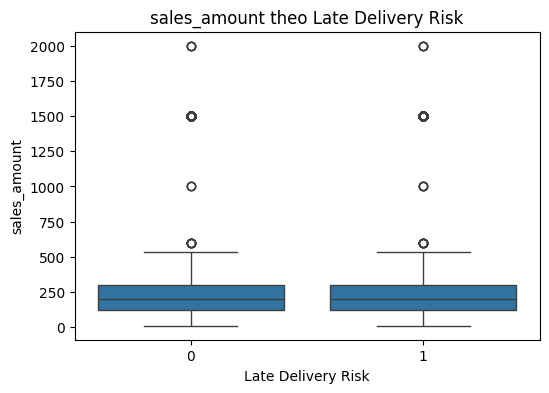

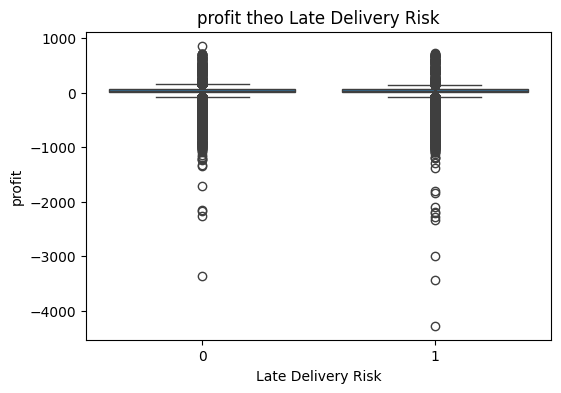

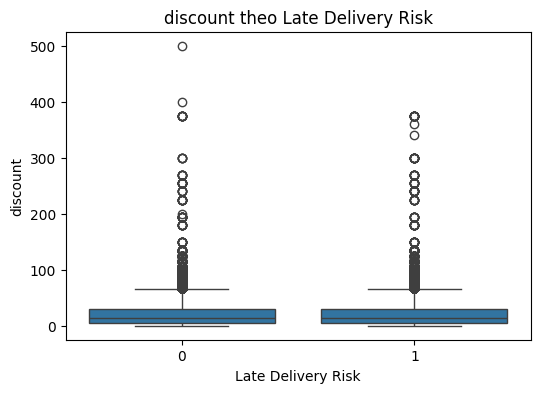

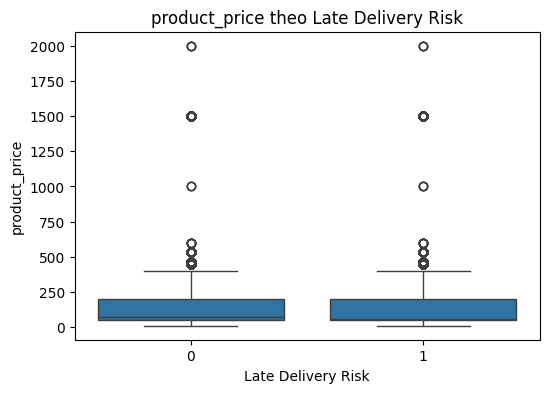

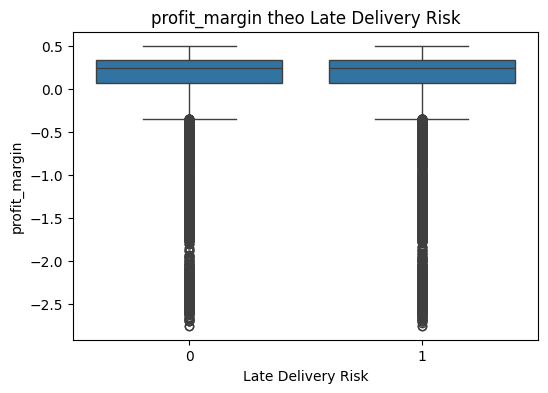

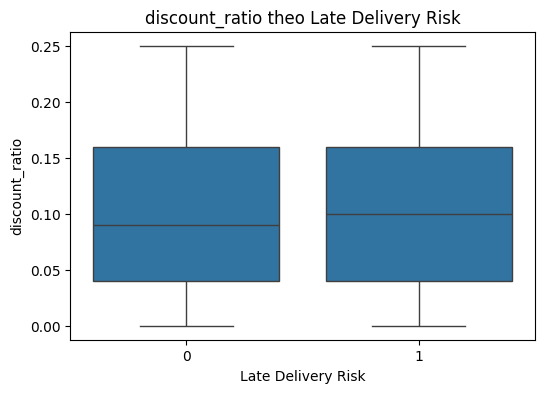

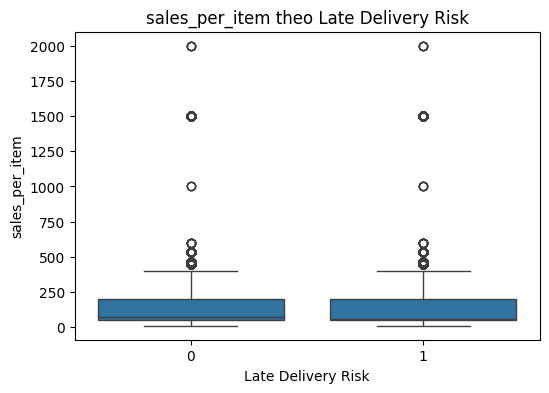

In [ ]:
# 9. Boxplot các biến số theo nhãn mục tiêu
box_cols = [
    "sales_amount",
    "profit",
    "discount",
    "product_price",
    "profit_margin",
    "discount_ratio",
    "sales_per_item"
]

for col in box_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=gold, x=target_col, y=col)
    plt.title(f"{col} theo Late Delivery Risk")
    plt.xlabel("Late Delivery Risk")
    plt.ylabel(col)
    plt.show()

In [ ]:
region_risk = (
    gold.groupby("order_region")[target_col]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

region_risk["late_risk_rate_percent"] = (region_risk[target_col] * 100).round(2)

region_risk.head(10)

,order_region,late_delivery_risk,late_risk_rate_percent
0,CENTRAL AFRICA,0.570922,57.09
1,NORTH AFRICA,0.567976,56.80
2,WESTERN EUROPE,0.562577,56.26
3,EAST AFRICA,0.560922,56.09
4,SOUTH ASIA,0.559448,55.94
5,SOUTHEAST ASIA,0.558683,55.87
6,EAST OF USA,0.557575,55.76
7,SOUTH OF USA,0.557178,55.72
8,CENTRAL AMERICA,0.555266,55.53
9,US CENTER,0.552404,55.24


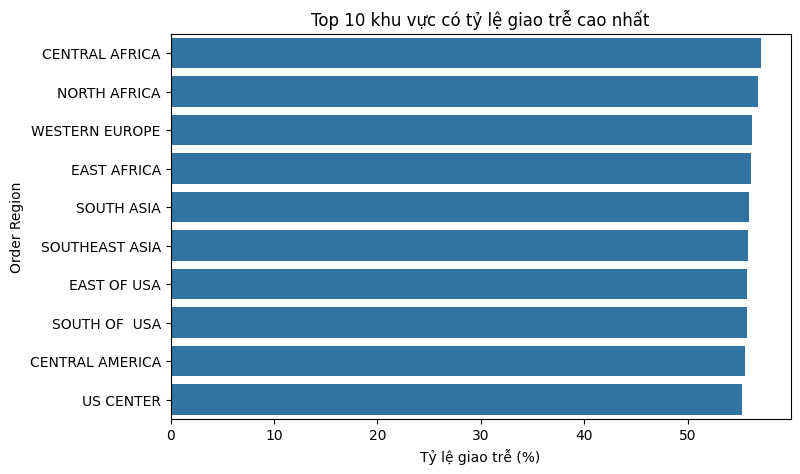

In [ ]:
# 12. Tỷ lệ giao trễ theo khu vực giao hàng
plt.figure(figsize=(8, 5))
sns.barplot(
    data=region_risk.head(10),
    y="order_region",
    x="late_risk_rate_percent"
)
plt.title("Top 10 khu vực có tỷ lệ giao trễ cao nhất")
plt.xlabel("Tỷ lệ giao trễ (%)")
plt.ylabel("Order Region")
plt.show()

In [ ]:
# 13. Tỷ lệ giao trễ theo cuối tuần và ngày thường
weekend_risk = (
    gold.groupby("is_weekend")[target_col]
    .mean()
    .reset_index()
)

weekend_risk["late_risk_rate_percent"] = (weekend_risk[target_col] * 100).round(2)

weekend_risk

,is_weekend,late_delivery_risk,late_risk_rate_percent
0,0,0.549595,54.96
1,1,0.548250,54.82


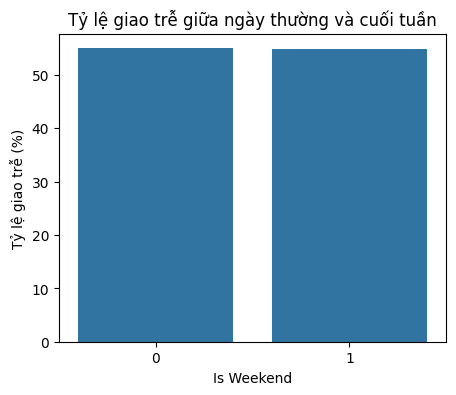

In [ ]:
plt.figure(figsize=(5, 4))
sns.barplot(data=weekend_risk, x="is_weekend", y="late_risk_rate_percent")
plt.title("Tỷ lệ giao trễ giữa ngày thường và cuối tuần")
plt.xlabel("Is Weekend")
plt.ylabel("Tỷ lệ giao trễ (%)")
plt.show()

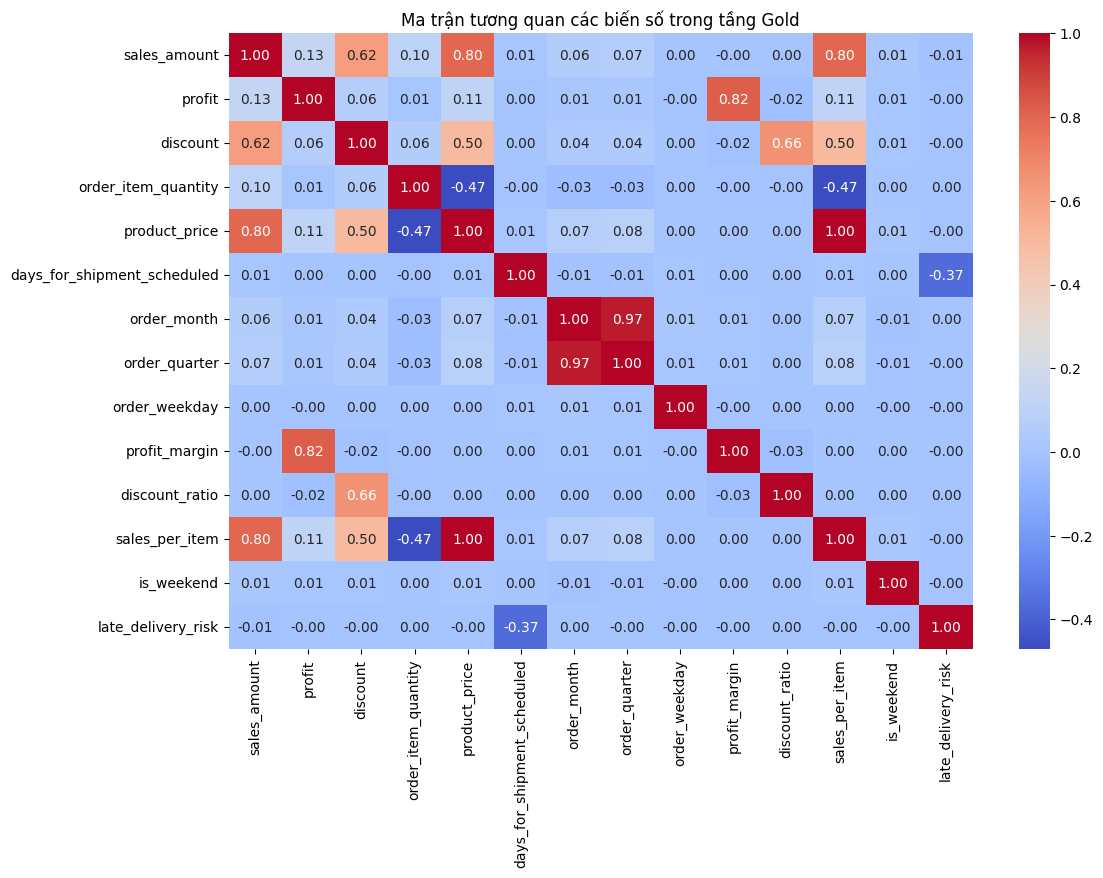

In [ ]:
# 14. Ma trận tương quan các biến số
corr_cols = [
    "sales_amount",
    "profit",
    "discount",
    "order_item_quantity",
    "product_price",
    "days_for_shipment_scheduled",
    "order_month",
    "order_quarter",
    "order_weekday",
    "profit_margin",
    "discount_ratio",
    "sales_per_item",
    "is_weekend",
    "late_delivery_risk"
]

corr_matrix = gold[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Ma trận tương quan các biến số trong tầng Gold")
plt.show()

In [ ]:
# 14. Kiểm tra các feature engineering
engineered_features = [
    "profit_margin",
    "discount_ratio",
    "sales_per_item",
    "is_weekend"
]

gold[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
profit_margin,114187.0,0.107382,0.422602,-2.75,0.062200,0.242516,0.336017,0.500143
discount_ratio,114187.0,0.101331,0.070579,0.00,0.040003,0.099653,0.160008,0.250433
sales_per_item,114187.0,141.985122,141.130661,9.99,50.000000,59.990002,199.990005,1999.989990
is_weekend,114187.0,0.290497,0.453994,0.00,0.000000,0.000000,1.000000,1.000000


In [ ]:
# 16. Tổng hợp bộ dữ liệu đầu vào cho CatBoost
feature_cols = [
    "customer_segment",
    "customer_country",
    "customer_state",
    "shipping_mode",
    "market",
    "order_region",
    "order_type",
    "category_name",
    "department_name",
    "product_price",
    "sales_amount",
    "profit",
    "discount",
    "order_item_quantity",
    "days_for_shipment_scheduled",
    "order_month",
    "order_quarter",
    "order_weekday",
    "profit_margin",
    "discount_ratio",
    "sales_per_item",
    "is_weekend"
]

target_col = "late_delivery_risk"

print("Số lượng feature:", len(feature_cols))
print("Target:", target_col)

X = gold[feature_cols]
y = gold[target_col]

X.head()

Số lượng feature: 22
Target: late_delivery_risk


,customer_segment,customer_country,customer_state,shipping_mode,market,order_region,order_type,category_name,department_name,product_price,...,discount,order_item_quantity,days_for_shipment_scheduled,order_month,order_quarter,order_weekday,profit_margin,discount_ratio,sales_per_item,is_weekend
0,CONSUMER,PUERTO RICO,PR,Standard Class,PACIFIC ASIA,SOUTHEAST ASIA,DEBIT,Sporting Goods,Fitness,327.75,...,13.110000,1,4,1,1,3,0.278413,0.040000,327.75,0
1,HOME OFFICE,EE. UU.,CA,Standard Class,PACIFIC ASIA,OCEANIA,DEBIT,Sporting Goods,Fitness,327.75,...,22.940001,1,4,1,1,6,0.069748,0.069992,327.75,1
2,CORPORATE,PUERTO RICO,PR,Standard Class,PACIFIC ASIA,OCEANIA,PAYMENT,Sporting Goods,Fitness,327.75,...,29.500000,1,4,1,1,6,0.409489,0.090008,327.75,1
3,CONSUMER,EE. UU.,NY,Standard Class,PACIFIC ASIA,OCEANIA,TRANSFER,Sporting Goods,Fitness,327.75,...,32.779999,1,4,1,1,6,0.056690,0.100015,327.75,1
4,HOME OFFICE,PUERTO RICO,PR,First Class,PACIFIC ASIA,EASTERN ASIA,DEBIT,Sporting Goods,Fitness,327.75,...,39.330002,1,1,1,1,6,0.290404,0.120000,327.75,1
